# Features measurements

This notebook is meant to compile all my work concerning features extractions of the detected foci. 
Features of interest:
- area/diameter 
- intensity

In [102]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas import DataFrame, Series  # for convenience
from pathlib import Path
from scipy.stats import linregress
from skimage.filters import threshold_yen,try_all_threshold, threshold_minimum, threshold_otsu
from skimage.measure import label
from scipy import ndimage

import warnings

import sys

my_path = Path.cwd().parent.parent / "src"
sys.path.append(str(my_path))

from visualization import visualization,plots
from utils import utils

%matplotlib inline

In [ ]:
ROOT = Path(r"K:\users\voland\data\current\TgCetnEos_CenSpark_H2B_4h-24h-48hpf\20260507CFHa_CetnEos_H2BmCherry_CS_48hpf\4e6")

VOL_PATH = ROOT /"subsets"/"s1_20260507CFHa_CetnEos_H2BmCherry_CS_48hpf.lif - 4e6-1.tif"

ct_centers_df_PATH = ROOT/"results"/"detection"/"curated"/"ct_res"/"c1_centers.csv"
cs_centers_df_PATH = ROOT/"results"/"detection"/"curated"/"cs_res"/"c3_centers.csv"

In [104]:
CT_CHANNEL_ID = 0
CS_CHANNEL_ID = 2

In [145]:
vol = tifffile.imread(VOL_PATH)
ct_vol = vol[:,CT_CHANNEL_ID]
cs_vol = vol[:,CS_CHANNEL_ID]

ct_centers_df = pd.read_csv(ct_centers_df_PATH)
cs_centers_df = pd.read_csv(cs_centers_df_PATH)

scale = utils.get_pixel_size(VOL_PATH)

Let's stard by visually checking some foci

In [149]:
WINDOW_TEST = slice(70,75)
WINDOW_SIZE = 40
WINDOW_SIZE * scale[1]

np.float64(6.051636801334749)

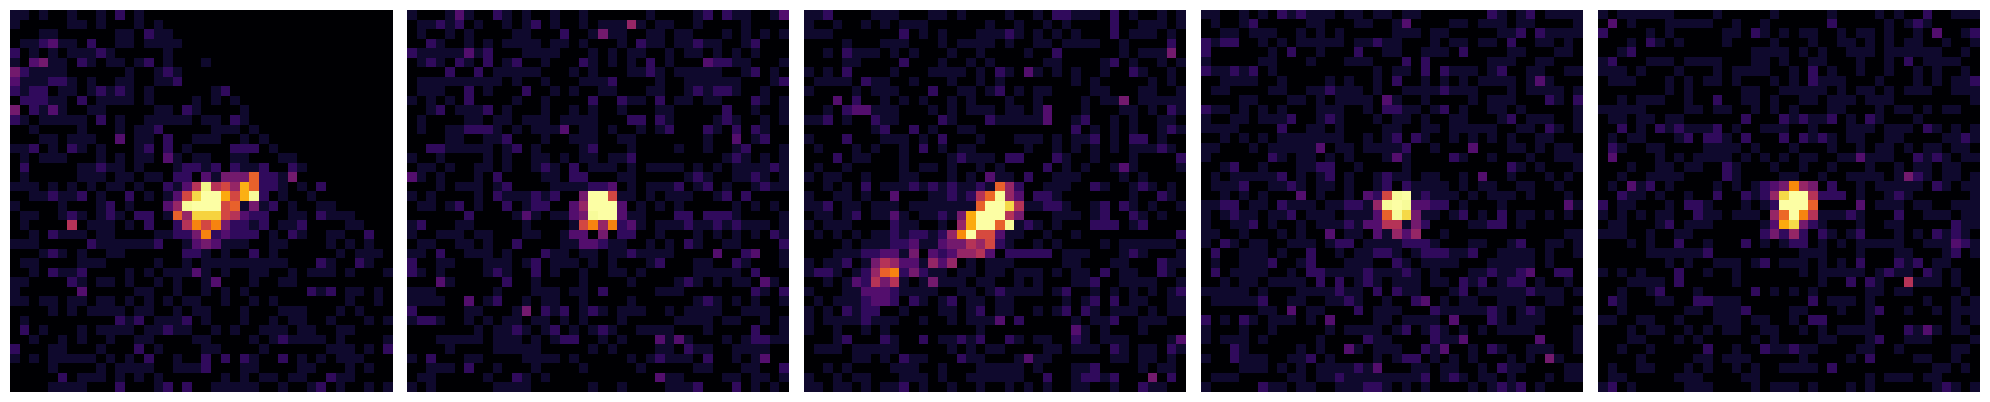

In [150]:
ct_points_ex = ct_centers_df[["Z","Y","X"]].iloc[WINDOW_TEST].values.astype(int)
plots.plot_points_closeup(ct_vol,ct_points_ex,window_size=WINDOW_SIZE,z_margin=1)

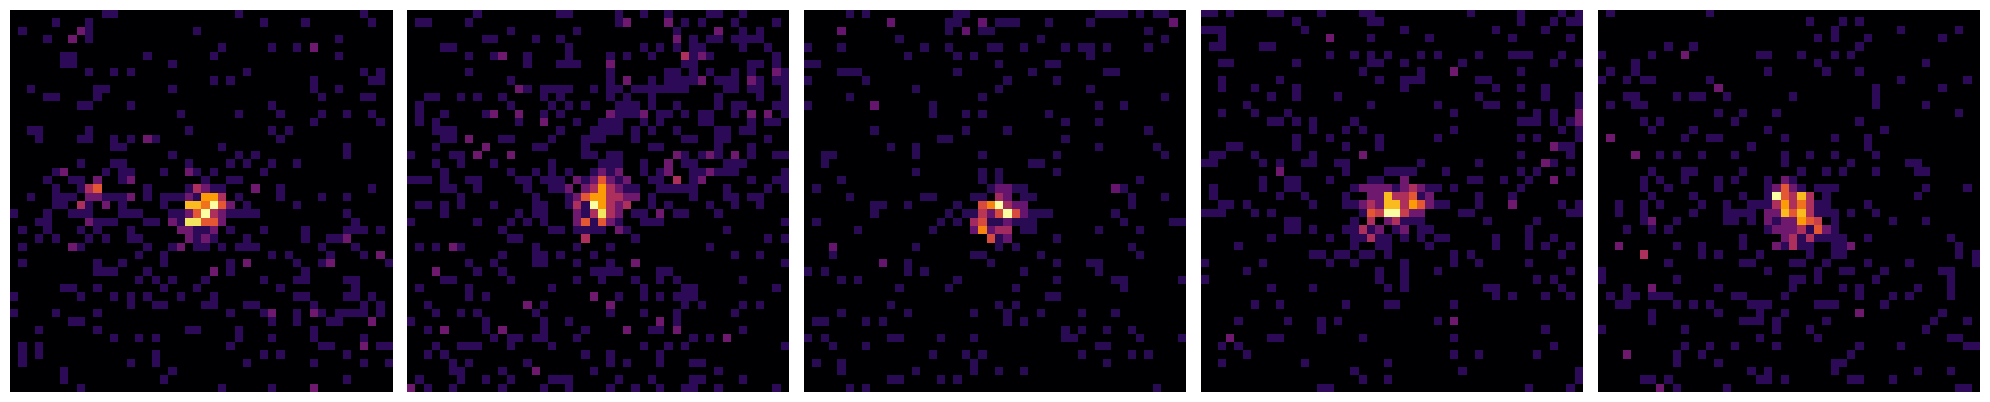

In [108]:
cs_points_ex = cs_centers_df[["Z","Y","X"]].iloc[WINDOW_TEST].values.astype(int)
plots.plot_points_closeup(cs_vol,cs_points_ex,z_margin=1)

Let's work a bit with the first spot of ct

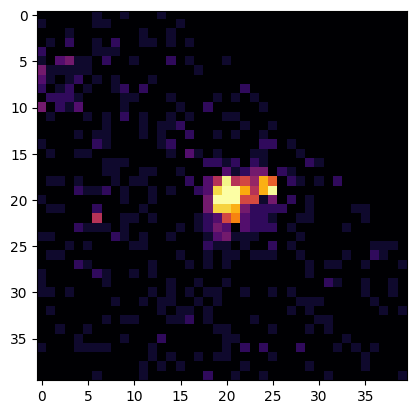

In [109]:
ct_spot1 = ct_points_ex[0]
ct_window_range = utils.get_window_range(WINDOW_SIZE, ct_spot1[1:3], ct_vol.shape[1:3])
ct_windowed_spot1 = utils.get_windowed_coord(WINDOW_SIZE, ct_spot1,ct_vol.shape)

ct_img1 = ct_vol[ct_spot1[0]][ct_window_range]
plt.imshow(ct_img1,cmap = "inferno")

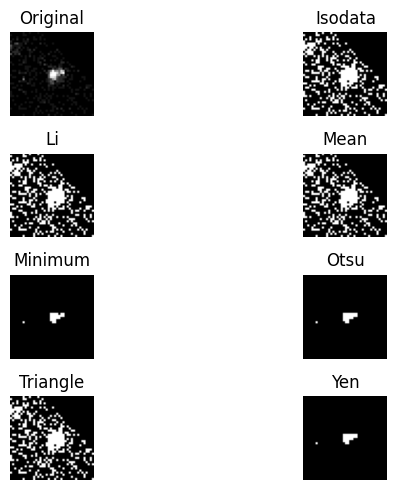

In [110]:
try_all_threshold(ct_img1, verbose=False);

Otsu, yen and minimum work  quite well.

Let's try to get the area/diameter 

In [111]:
def try_tresholding(img,spot):
    y,x = spot[1:3]
    otsu_img = img > threshold_otsu(img)
    otsu_labels, nshapes = label(otsu_img, return_num=True)
    area = ndimage.sum(otsu_img, labels=otsu_labels, index=otsu_labels[y,x])
    diameter = np.sqrt(area/np.pi)*2
    intensity = img[y,x]
    print("Otsu thresholding:")
    print(f" -- area: {area}")
    print(f" -- diameter: {diameter}")
    print(f" -- intesity: {intensity} ")

    yen_img = img > threshold_yen(img)
    yen_labels, nshapes = label(yen_img, return_num=True)
    area = ndimage.sum(yen_img, labels=yen_labels, index=yen_labels[y,x])
    diameter = np.sqrt(area/np.pi)*2
    intensity = img[y,x]
    print("Yen thresholding:")
    print(f" -- area: {area}")
    print(f" -- diameter: {diameter}")
    print(f" -- intesity: {intensity} ")

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    axes[0].imshow(img,cmap="inferno")
    axes[1].set_title("Original image")
    axes[1].imshow(otsu_img)
    axes[1].set_title("Otsu thresholding")
    axes[2].imshow(yen_img)
    axes[2].set_title("Yen thresholding")

Otsu thresholding:
 -- area: 24
 -- diameter: 5.527906391541368
 -- intesity: 255 
Yen thresholding:
 -- area: 24
 -- diameter: 5.527906391541368
 -- intesity: 255 


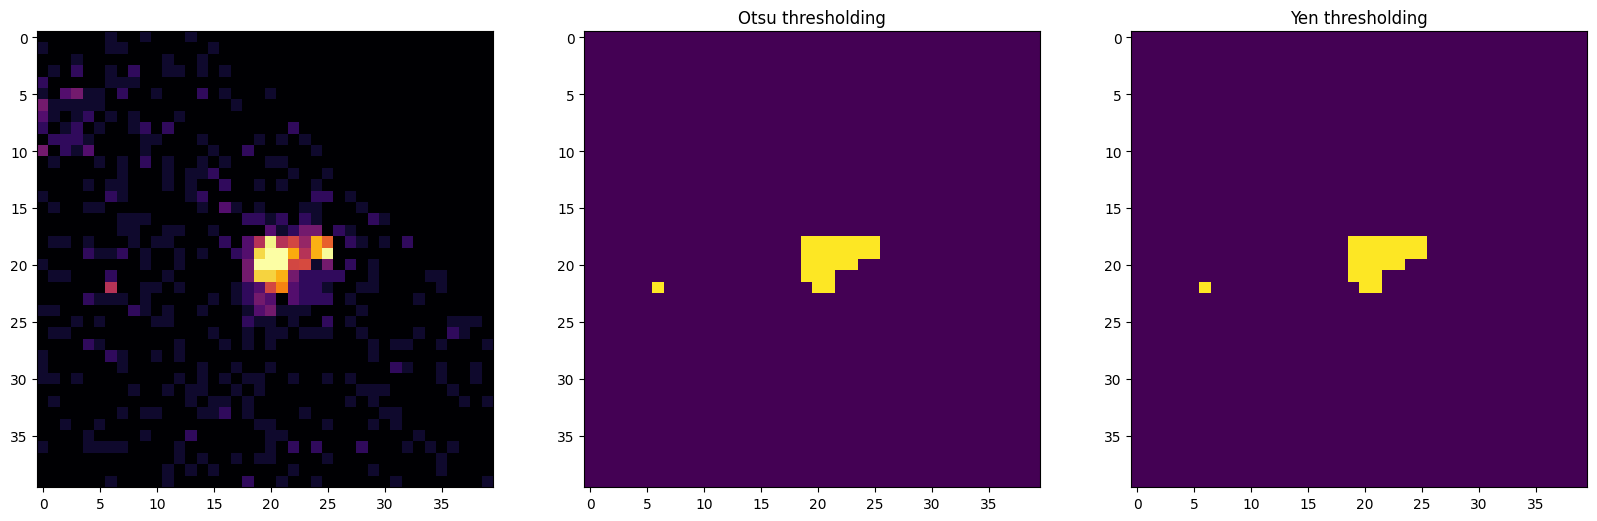

In [112]:
try_tresholding(ct_img1,ct_windowed_spot1)

Let's do the same with a CS spot.

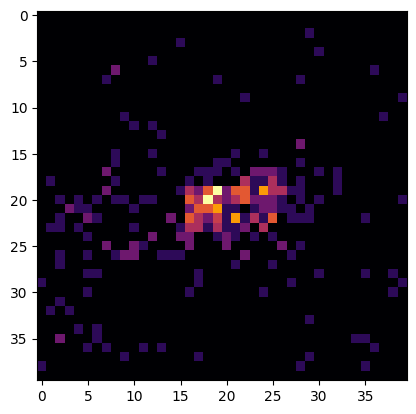

In [243]:
cs_spot1 = np.array([86,509,756]) #cs_points_ex[2]
cs_window_range = utils.get_window_range(WINDOW_SIZE, cs_spot1[1:3], cs_vol.shape[1:3])
cs_windowed_spot1 = utils.get_windowed_coord(WINDOW_SIZE, cs_spot1,cs_vol.shape)

cs_img1 = cs_vol[cs_spot1[0]][cs_window_range]
plt.imshow(cs_img1,cmap = "inferno")

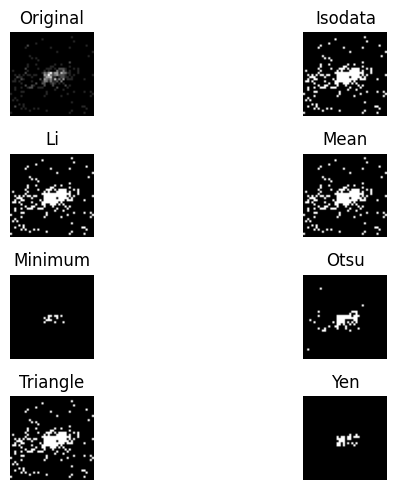

In [244]:
try_all_threshold(cs_img1, verbose=False);

Otsu thresholding:
 -- area: 48
 -- diameter: 7.817640190446719
 -- intesity: 74 
Yen thresholding:
 -- area: 0
 -- diameter: 0.0
 -- intesity: 74 


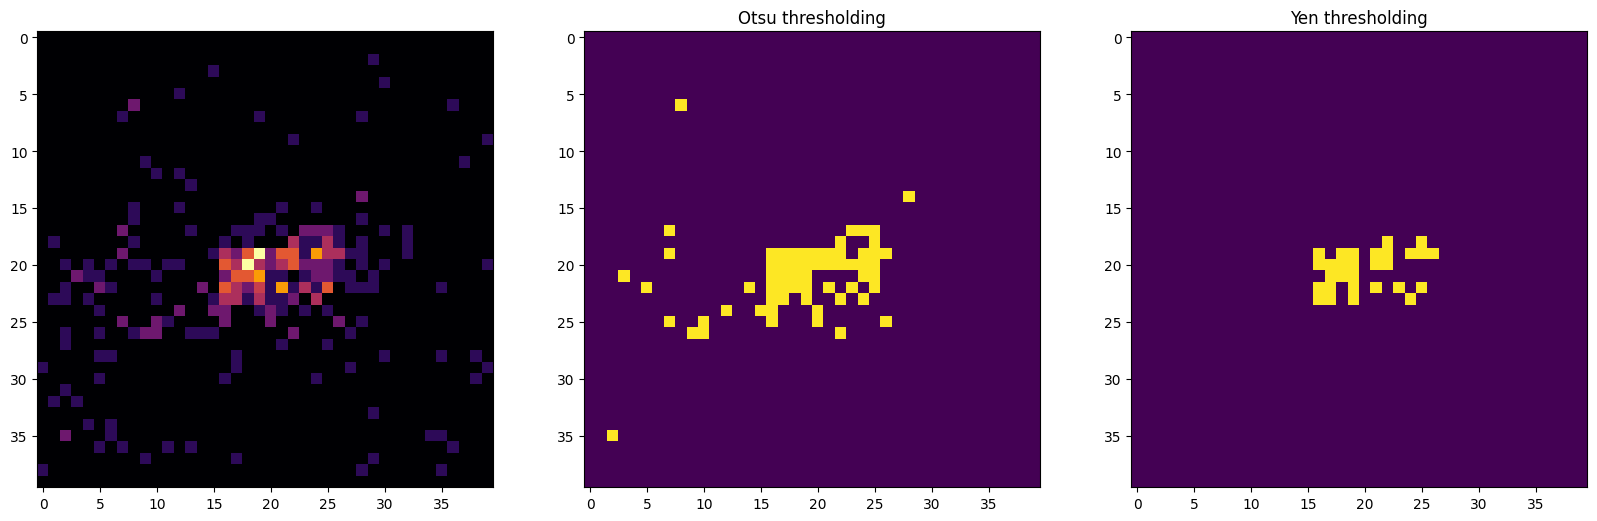

In [245]:
try_tresholding(cs_img1,cs_windowed_spot1)

We can see the limit of this approach

## Median filter

### CT channel

Let's also see the impact of applying a median filter

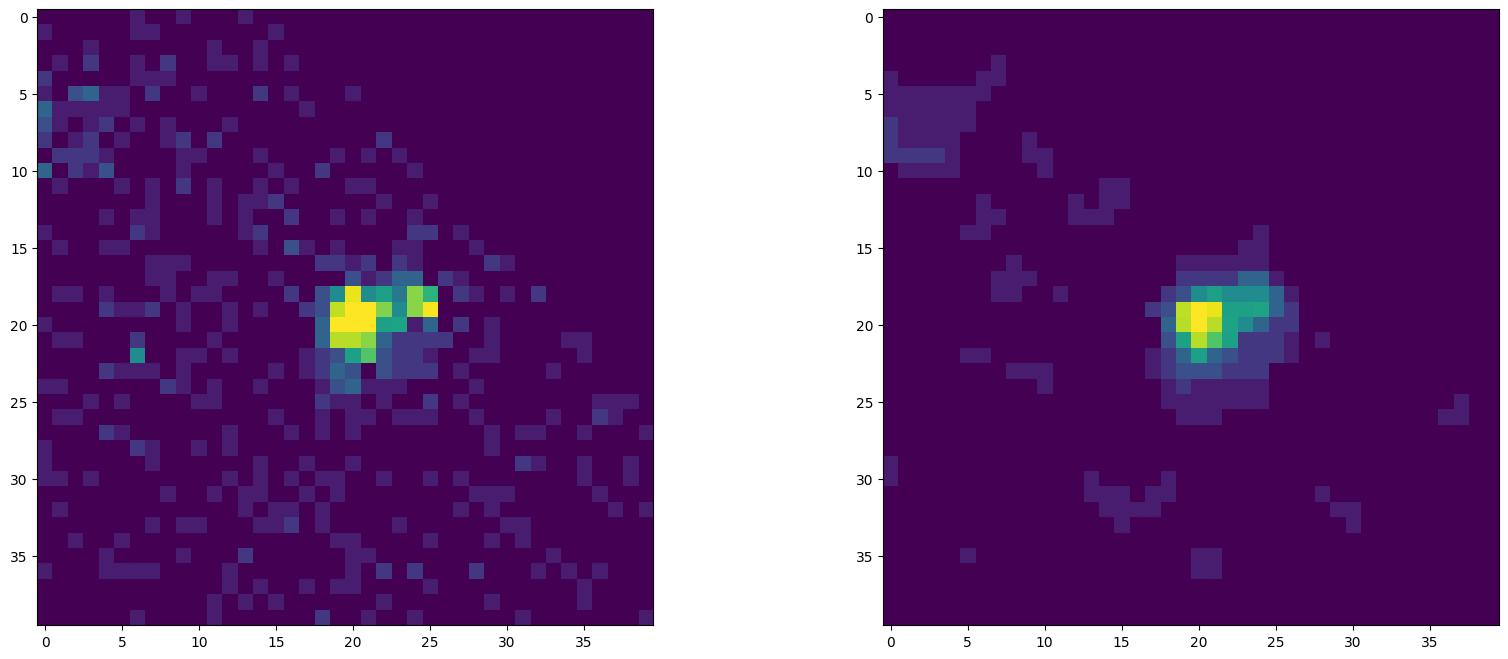

In [246]:
median_ct_img1 = ndimage.median_filter(ct_img1,size=3)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(ct_img1)
axes[1].imshow(median_ct_img1)

Otsu thresholding:
 -- area: 29
 -- diameter: 6.076507779746499
 -- intesity: 255 
Yen thresholding:
 -- area: 36
 -- diameter: 6.770275002573076
 -- intesity: 255 


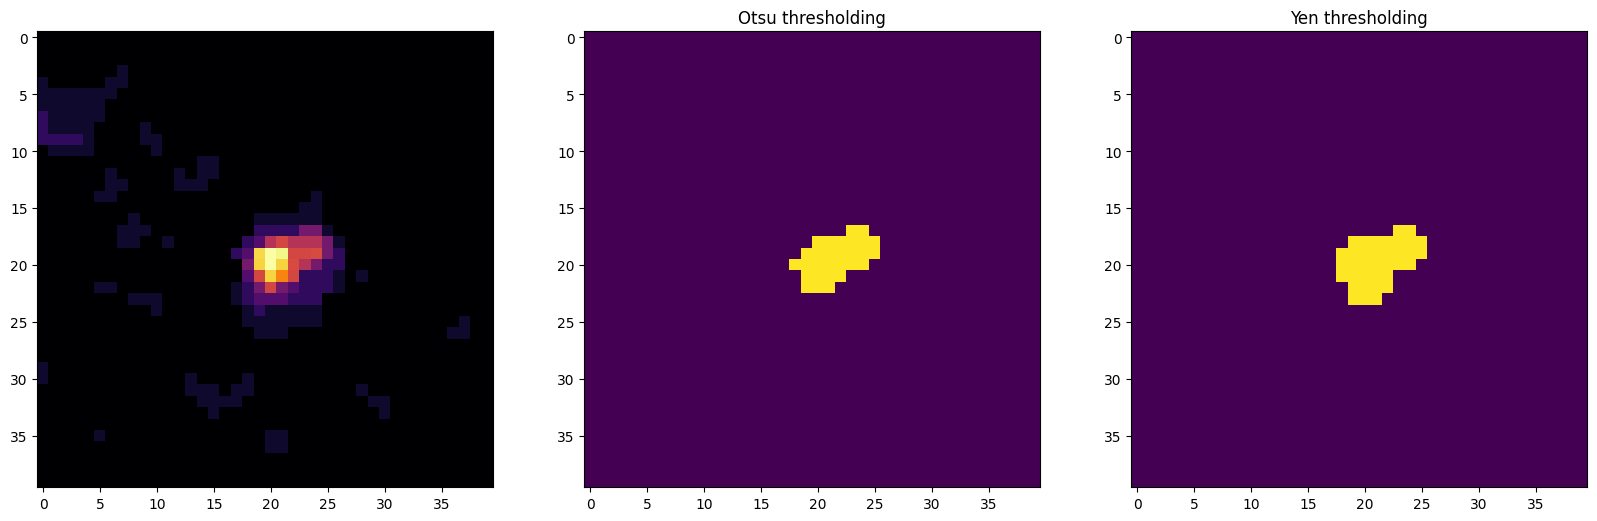

In [247]:
try_tresholding(median_ct_img1,ct_windowed_spot1)

### CS channel

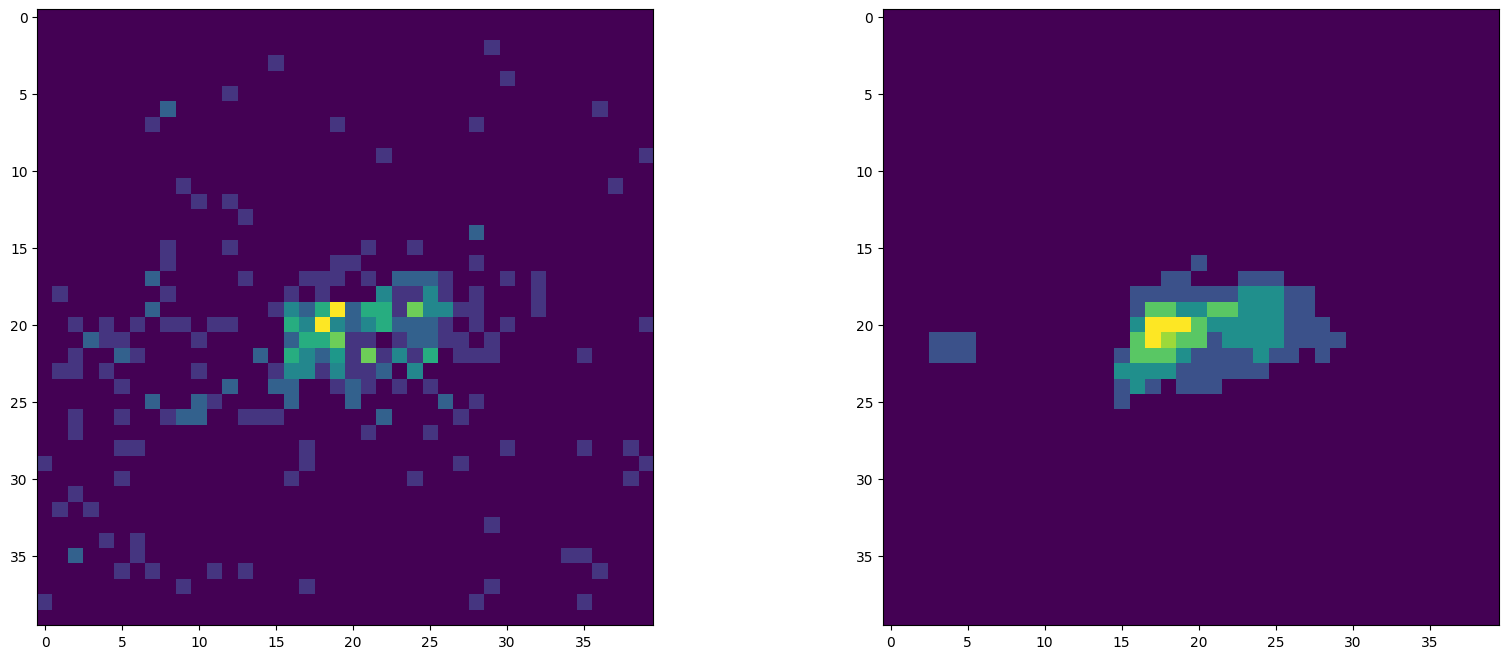

In [248]:
median_cs_img1 = ndimage.median_filter(cs_img1,size=3)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(cs_img1)
axes[1].imshow(median_cs_img1)

Otsu thresholding:
 -- area: 41
 -- diameter: 7.225151993843567
 -- intesity: 111 
Yen thresholding:
 -- area: 87
 -- diameter: 10.524820207108489
 -- intesity: 111 


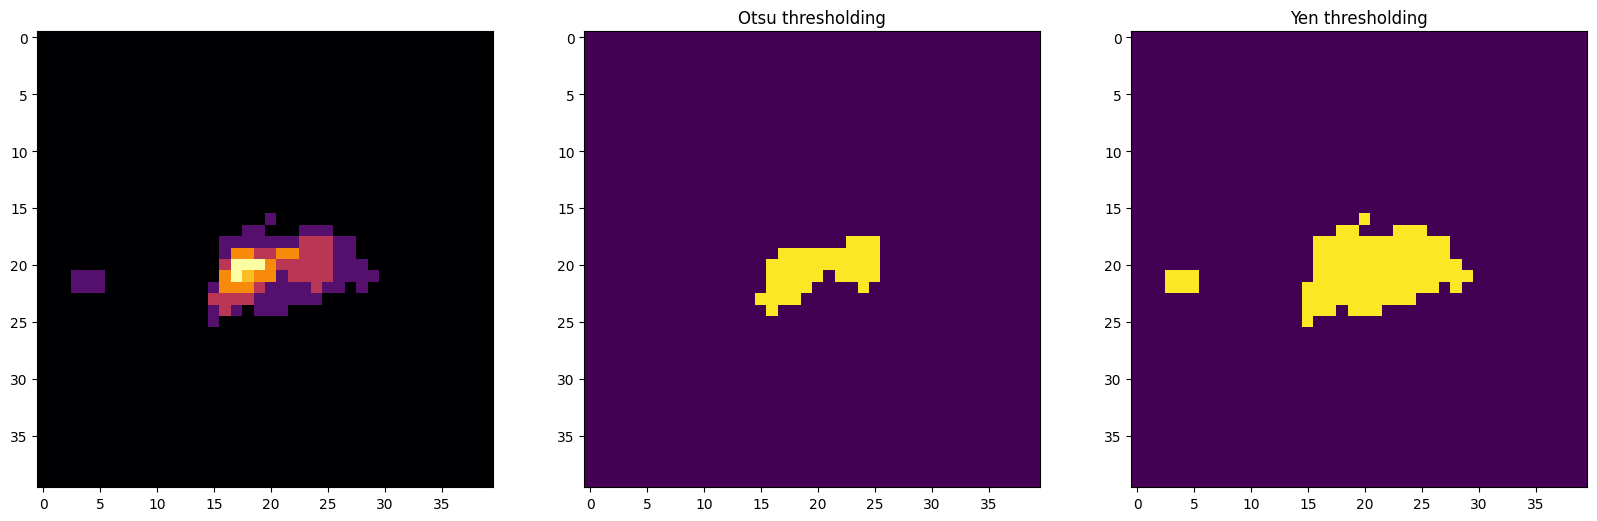

In [249]:
try_tresholding(median_cs_img1,cs_windowed_spot1)

We can note that Yen gives us larger area and diameter than Otsu.

## Gaussian filter 


### CT channel
We can also try with a gaussian filter

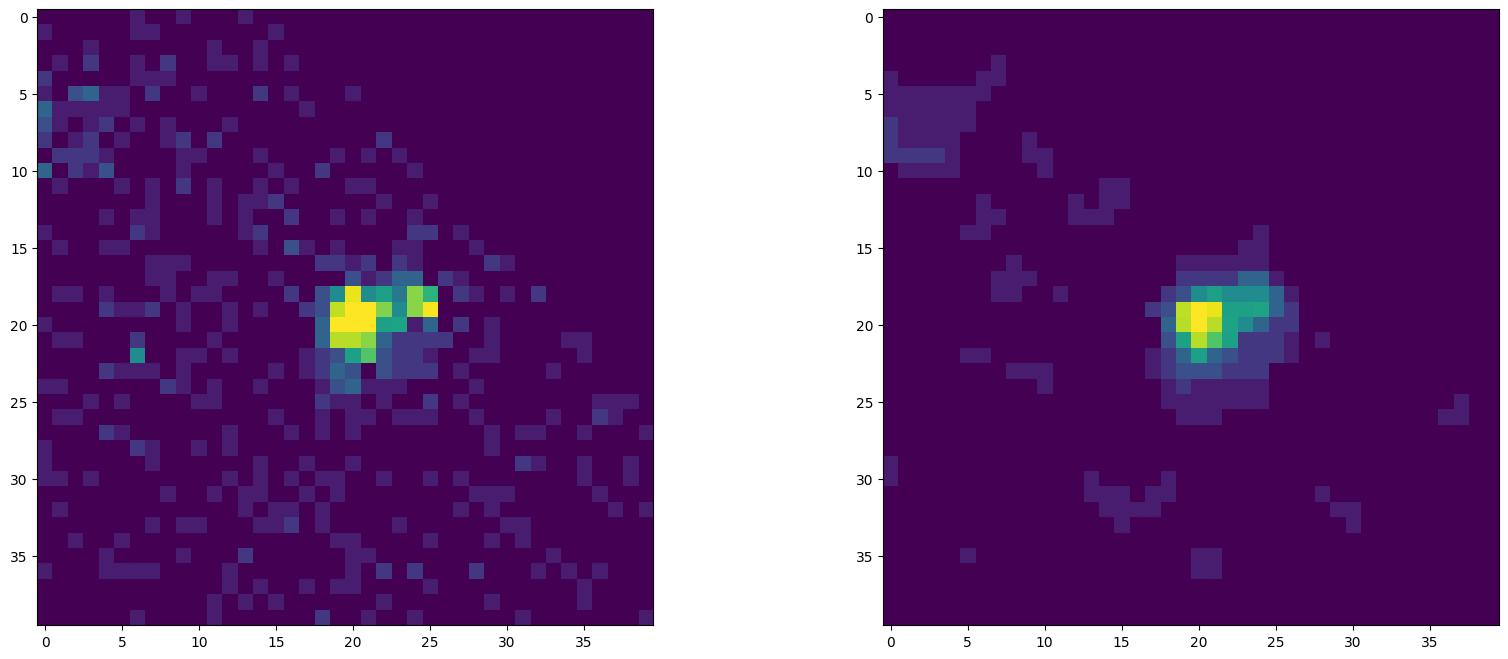

In [250]:
guassian_ct_img1 = ndimage.gaussian_filter(ct_img1,sigma=0.8)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(ct_img1)
axes[1].imshow(median_ct_img1)

Otsu thresholding:
 -- area: 36
 -- diameter: 6.770275002573076
 -- intesity: 236 
Yen thresholding:
 -- area: 58
 -- diameter: 8.593479713983122
 -- intesity: 236 


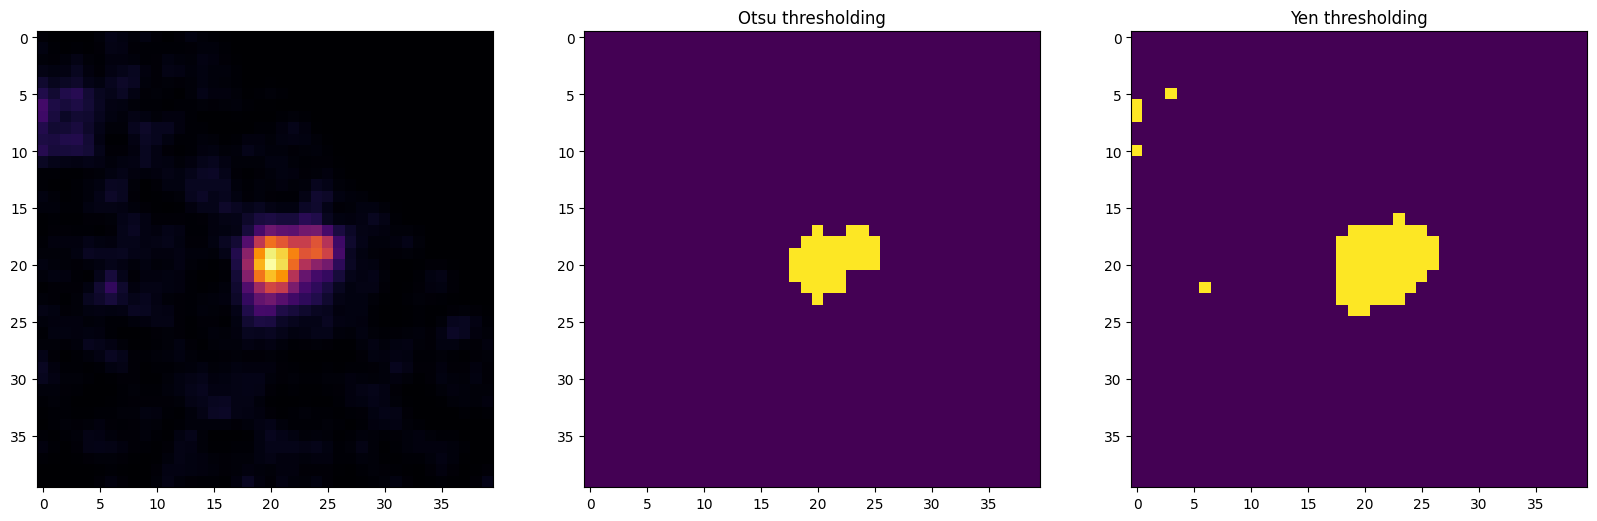

In [251]:
try_tresholding(guassian_ct_img1,ct_windowed_spot1)

### CS Channel

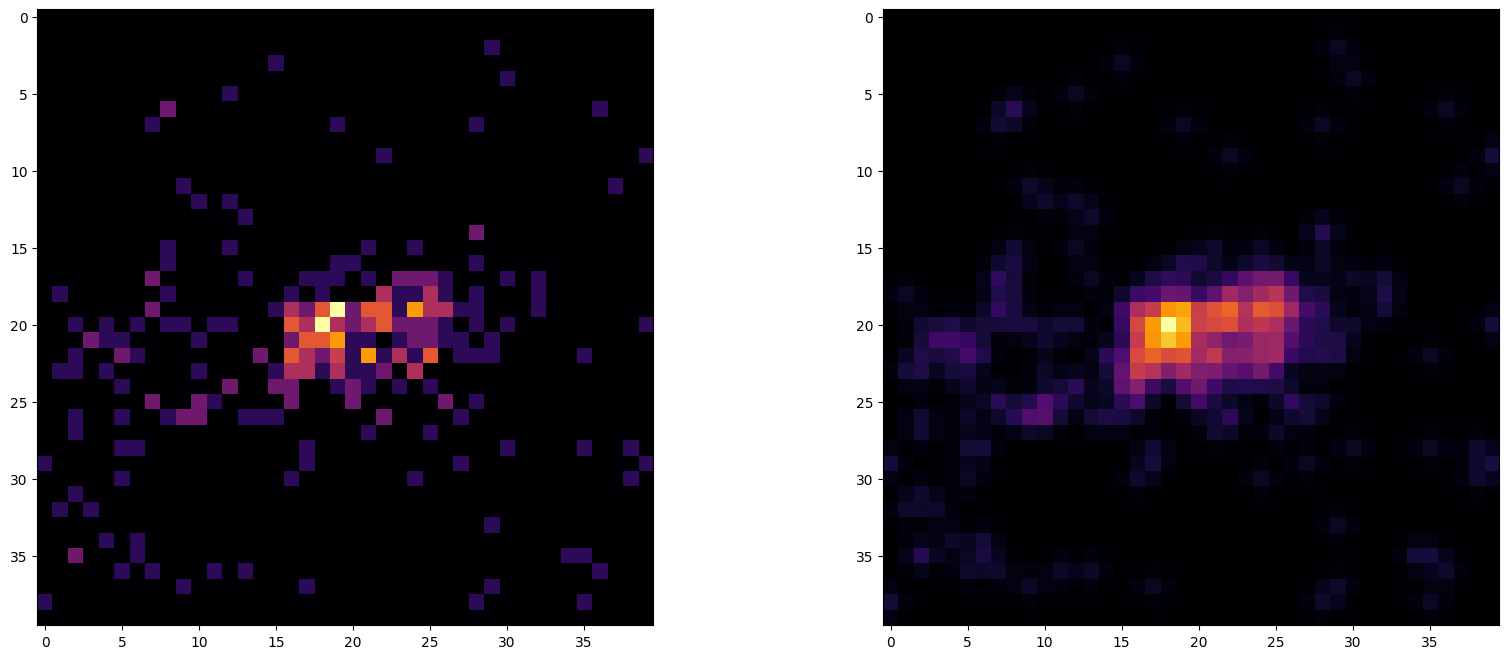

In [275]:
guassian_cs_img1 = ndimage.gaussian_filter(cs_img1,sigma=0.7)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(cs_img1,cmap="inferno")
axes[1].imshow(guassian_cs_img1,cmap="inferno")

Otsu thresholding:
 -- area: 65
 -- diameter: 9.09728368293446
 -- intesity: 92 
Yen thresholding:
 -- area: 84
 -- diameter: 10.341765891652821
 -- intesity: 92 


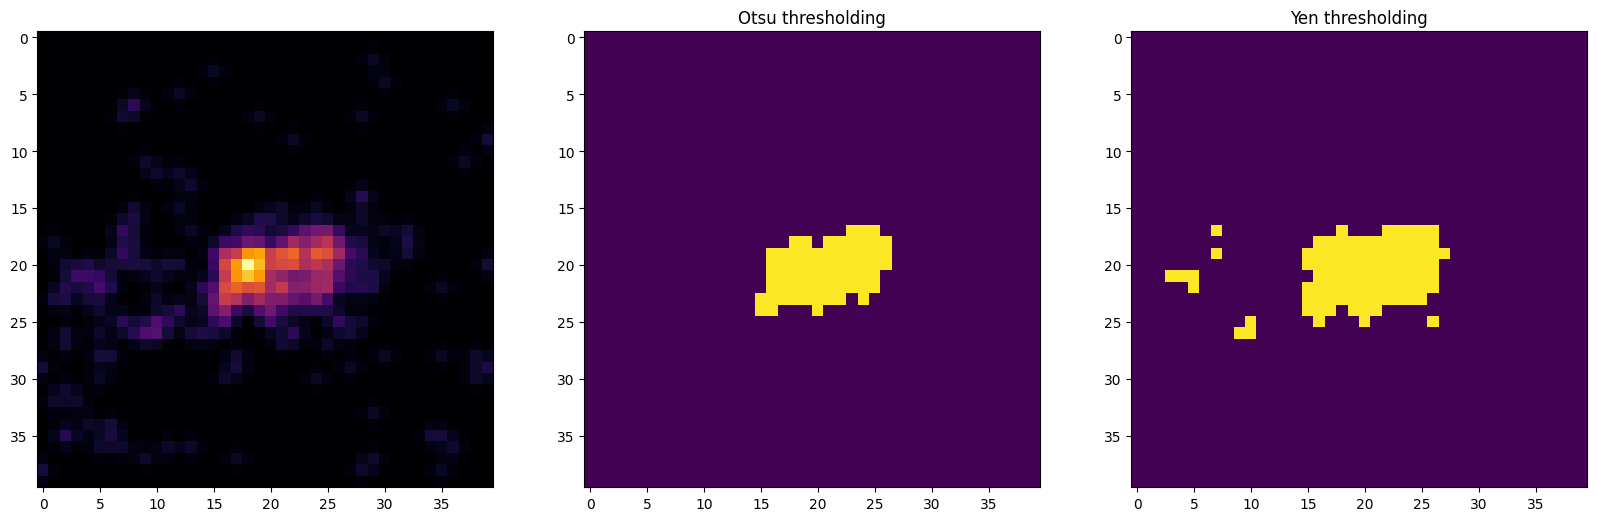

In [287]:
try_tresholding(guassian_cs_img1,cs_windowed_spot1)

Otus with Gaussian blurr seems to be the best option.

## Optimization

We would like to see if it would be better to apply the Gaussian filter and the thresholding on the entire image or on the cropped obe.

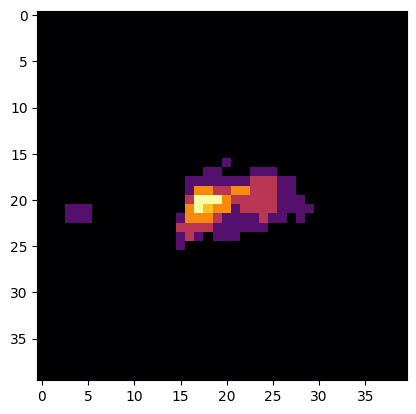

In [254]:
median_cs_img = ndimage.median_filter(cs_vol[cs_spot1[0]],size=3)

plt.imshow(median_cs_img[cs_window_range],cmap = "inferno")

Otsu thresholding:
 -- area: 87
 -- diameter: 10.524820207108489
 -- intesity: 111 
Yen thresholding:
 -- area: 0
 -- diameter: 0.0
 -- intesity: 111 


Text(0.5, 1.0, 'Yen thresholding')

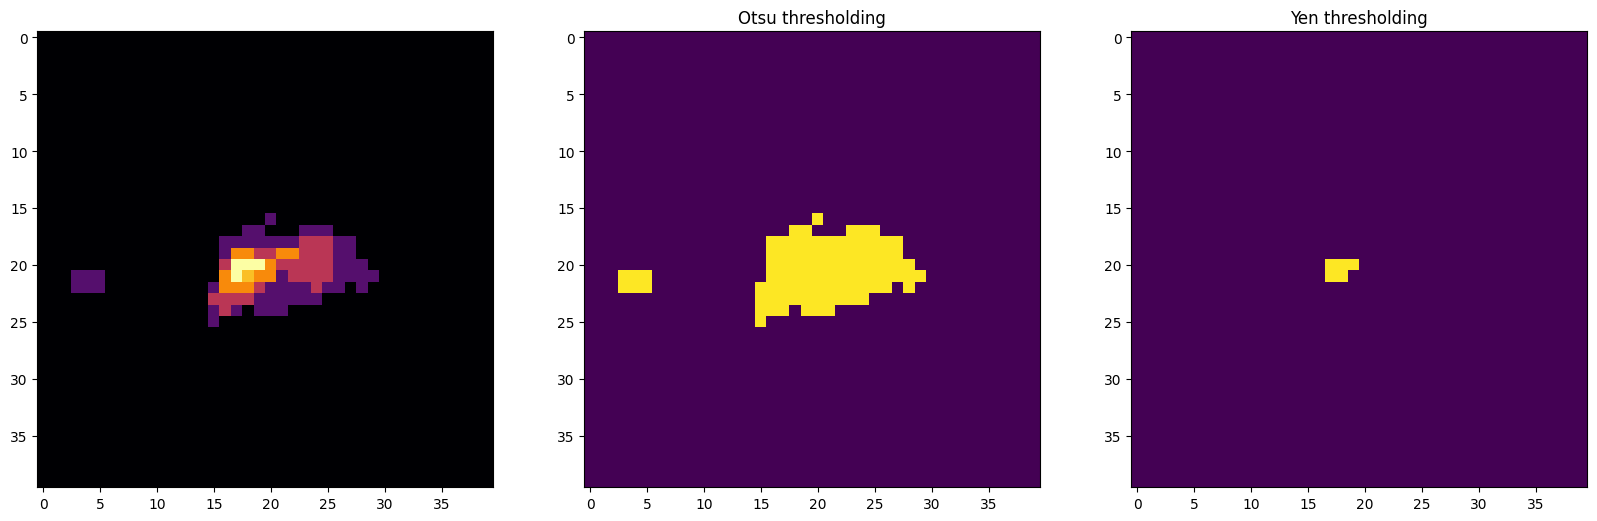

In [255]:
y,x = cs_spot1[1:3]
otsu_img = median_cs_img > threshold_otsu(median_cs_img)
otsu_labels, nshapes = label(otsu_img, return_num=True)
area = ndimage.sum(otsu_img, labels=otsu_labels, index=otsu_labels[y,x])
diameter = np.sqrt(area/np.pi)*2
intensity = median_cs_img[y,x]
print("Otsu thresholding:")
print(f" -- area: {area}")
print(f" -- diameter: {diameter}")
print(f" -- intesity: {intensity} ")

yen_img = median_cs_img > threshold_yen(median_cs_img)
yen_labels, nshapes = label(yen_img, return_num=True)
area = ndimage.sum(yen_img, labels=yen_labels, index=yen_labels[y,x])
diameter = np.sqrt(area/np.pi)*2
intensity = median_cs_img[y,x]
print("Yen thresholding:")
print(f" -- area: {area}")
print(f" -- diameter: {diameter}")
print(f" -- intesity: {intensity} ")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes[0].imshow(median_cs_img[cs_window_range],cmap="inferno")
axes[1].set_title("Original image")
axes[1].imshow(otsu_img[cs_window_range])
axes[1].set_title("Otsu thresholding")
axes[2].imshow(yen_img[cs_window_range])
axes[2].set_title("Yen thresholding")

We don't really see any differences when working with median and yen globally or locally.

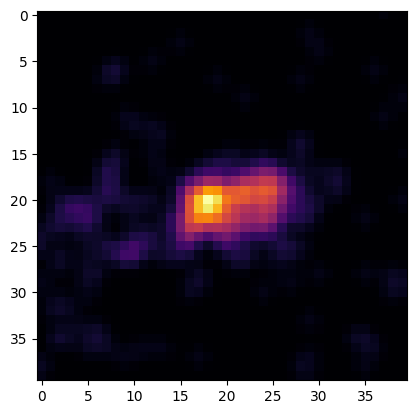

In [256]:
guassian_cs_img = ndimage.gaussian_filter(cs_vol[cs_spot1[0]],sigma=1)

plt.imshow(guassian_cs_img[cs_window_range],cmap = "inferno")


Yen thresholding:
 -- area: 177.31295827910813
 -- radius: 1.1366013443514307
 -- intesity: 99 
Yen thresholding:
 -- area: 10.59036440233581
 -- radius: 0.2777751428129669
 -- intesity: 99 


Text(0.5, 1.0, 'Yen thresholding')

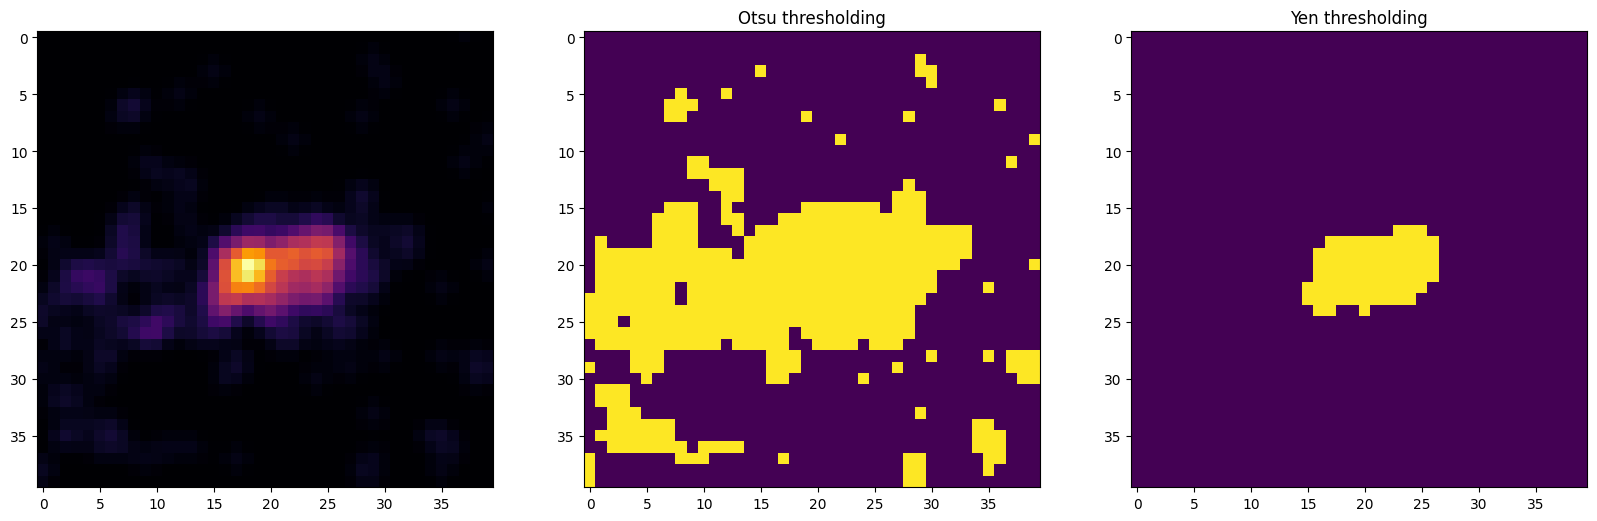

In [257]:
y,x = cs_spot1[1:3]
otsu_img = guassian_cs_img > threshold_otsu(guassian_cs_img)
otsu_labels, nshapes = label(otsu_img, return_num=True)
area = ndimage.sum(otsu_img, labels=otsu_labels, index=otsu_labels[y,x]) * scale[1]
radius = np.sqrt(area/np.pi) * scale[1]
intensity = guassian_cs_img[y,x]
print("Yen thresholding:")
print(f" -- area: {area}")
print(f" -- radius: {radius}")
print(f" -- intesity: {intensity} ")

yen_img = guassian_cs_img > threshold_yen(guassian_cs_img)
yen_labels, nshapes = label(yen_img, return_num=True)
area = ndimage.sum(yen_img, labels=yen_labels, index=yen_labels[y,x]) * scale[1]
radius = np.sqrt(area/np.pi) * scale[1]
intensity = guassian_cs_img[y,x]
print("Yen thresholding:")
print(f" -- area: {area}")
print(f" -- radius: {radius}")
print(f" -- intesity: {intensity} ")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes[0].imshow(guassian_cs_img[cs_window_range],cmap="inferno")
axes[1].set_title("Original image")
axes[1].imshow(otsu_img[cs_window_range])
axes[1].set_title("Otsu thresholding")
axes[2].imshow(yen_img[cs_window_range])
axes[2].set_title("Yen thresholding")

When working gloabbly, yen is way better.

The median filter seems to preserve more accuratly the intensity of the spot.
Let's try to apply to obtain the area and intensity of all the spots and see if we have 0 values.

### Channel CT

In [258]:
ct_centers = ct_centers_df[["Z","Y","X"]].values

areas = np.empty(len(ct_centers))
diameters = np.empty(len(ct_centers))
intensities = np.empty(len(ct_centers))

for i, ct_center in enumerate(ct_centers):
    z,y,x = ct_center.astype(int)
    window_range = utils.get_window_range(WINDOW_SIZE, ct_center[1:3], ct_vol.shape[1:3])
    wz,wy,wx = utils.get_windowed_coord(WINDOW_SIZE, ct_center,ct_vol.shape).astype(int)

    ct_img = ct_vol[z][window_range]
    #median_cs_img = ndimage.median_filter(cs_img,size=3)
    gaussian_ct_img = ndimage.gaussian_filter(ct_img,sigma=1)
    yen_cs_img = gaussian_ct_img > threshold_yen(gaussian_ct_img)

    yen_labels, nshapes = label(yen_cs_img, return_num=True)
    areas[i] = ndimage.sum(yen_cs_img, labels=yen_labels, index=yen_labels[wy,wx])
    diameters[i] = np.sqrt(area/np.pi)*2
    intensities[i] = gaussian_ct_img[wy,wx]

ct_centers_df["area"] = areas
ct_centers_df["diameter"] = diameters 
ct_centers_df["intensitie"] = intensities  

ct_centers_df.head()

,index,Z,Y,X,R,area,diameter,intensitie
0,0,29.0,334.0,324.0,1.652446,48.0,3.672066,204.0
1,1,38.0,617.0,761.0,4.230260,147.0,3.672066,252.0
2,2,3.0,132.0,264.0,1.652446,42.0,3.672066,213.0
3,3,10.0,482.0,503.0,1.652446,47.0,3.672066,214.0
4,4,17.0,498.0,364.0,2.643913,91.0,3.672066,241.0


In [259]:
ct_centers_df[["area","diameter","intensitie"]].describe()

,area,diameter,intensitie
count,784.000000,7.840000e+02,784.000000
mean,45.073980,3.672066e+00,132.906888
std,23.030651,4.443727e-16,50.913146
min,5.000000,3.672066e+00,18.000000
25%,30.000000,3.672066e+00,88.750000
50%,40.000000,3.672066e+00,137.000000
75%,56.000000,3.672066e+00,175.250000
max,169.000000,3.672066e+00,252.000000


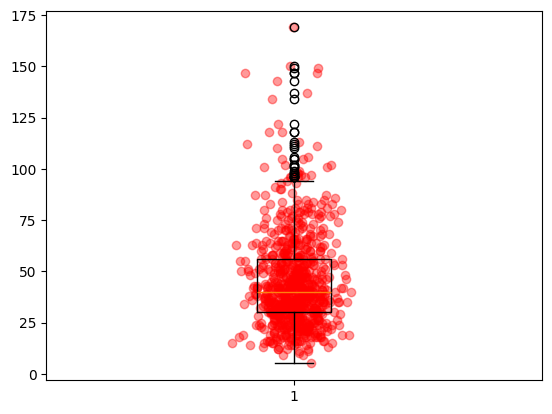

In [260]:
vals, names, xs = [],[],[]
vals.append(areas)
xs.append(np.random.normal(1, 0.04, len(ct_centers_df))) 

plt.boxplot(areas);
plt.scatter(xs,areas, alpha=0.4, color="red")

### Channel CS

In [261]:
cs_centers = cs_centers_df[["Z","Y","X"]].values

areas = np.empty(len(cs_centers))
diameters = np.empty(len(cs_centers))
intensities = np.empty(len(cs_centers))

for i, cs_center in enumerate(cs_centers):
    z,y,x = cs_center.astype(int)
    window_range = utils.get_window_range(WINDOW_SIZE, cs_center[1:3], cs_vol.shape[1:3])
    wz,wy,wx = utils.get_windowed_coord(WINDOW_SIZE, cs_center,cs_vol.shape).astype(int)

    cs_img = cs_vol[z][window_range]
    #median_cs_img = ndimage.median_filter(cs_img,size=3)
    gaussian_cs_img = ndimage.gaussian_filter(cs_img,sigma=1)
    yen_cs_img = gaussian_cs_img > threshold_yen(gaussian_cs_img)

    yen_labels, nshapes = label(yen_cs_img, return_num=True)
    areas[i] = ndimage.sum(yen_cs_img, labels=yen_labels, index=yen_labels[wy,wx])
    diameters[i] = np.sqrt(area/np.pi)*2
    intensities[i] = gaussian_cs_img[wy,wx]

cs_centers_df["area"] = areas
cs_centers_df["diameter"] = diameters 
cs_centers_df["intensitie"] = intensities  

cs_centers_df.head()

,index,Z,Y,X,R,area,diameter,intensitie
0,0,14.0,492.0,713.0,1.982935,70.0,3.672066,214.0
1,1,24.0,15.0,89.0,1.982935,51.0,3.672066,171.0
2,2,22.0,568.0,802.0,1.982935,93.0,3.672066,204.0
3,3,31.0,7.0,256.0,1.982935,51.0,3.672066,177.0
4,4,60.0,525.0,555.0,1.982935,61.0,3.672066,203.0


In [262]:
cs_centers_df[["area","diameter","intensitie"]].describe()

,area,diameter,intensitie
count,478.000000,478.000000,478.000000
mean,51.077406,3.672066,90.242678
std,24.037014,0.000000,38.004244
min,16.000000,3.672066,28.000000
25%,35.000000,3.672066,63.000000
50%,46.500000,3.672066,81.000000
75%,62.000000,3.672066,111.000000
max,178.000000,3.672066,215.000000


In [263]:
np.sqrt(180/np.pi)

np.float64(7.569397566060481)

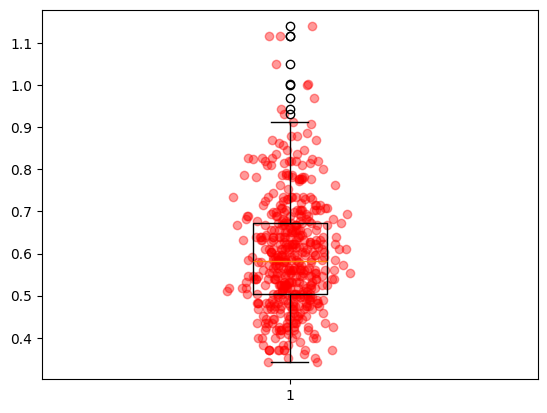

In [264]:
vals, names, xs = [],[],[]
xs.append(np.random.normal(1, 0.04, len(cs_centers_df))) 

radius = np.sqrt(areas/np.pi)*scale[1]
plt.boxplot(radius);
plt.scatter(xs,radius, alpha=0.4, color="red")

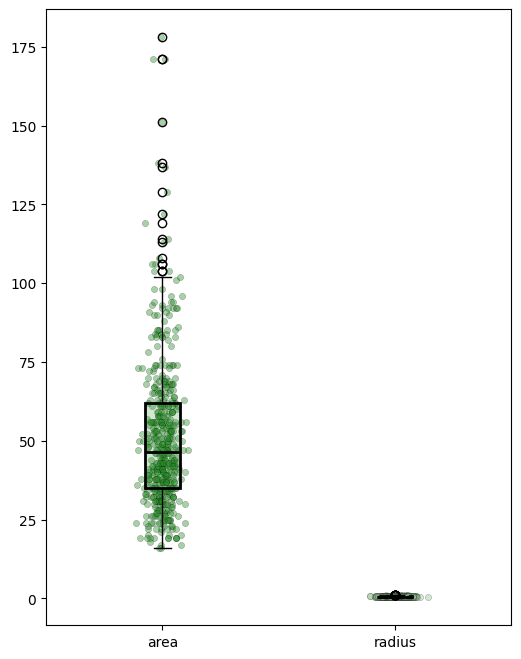

In [265]:
from matplotlib.colors import to_rgba

colors = ['forestgreen', 'darkseagreen']
linestyle = ["-","--"]
line_styles = list(linestyle)

fig, ax = plt.subplots(figsize=(6, 8))
values = [areas,radius]

labels = ["area","radius"]

bp = ax.boxplot(values, labels=labels, patch_artist=True, medianprops={"color": "black"})

for i, box in enumerate(bp["boxes"]):
    # Set facecolor with transparency, edgecolor with full opacity
    # Convert color name to RGBA, then set alpha to 0.2
    color_rgba = to_rgba(colors[i])
    facecolor_rgba = (*color_rgba[:3], 0.2)
    box.set_facecolor(facecolor_rgba)
    box.set_edgecolor("black")
    box.set_linestyle(line_styles[i])
    box.set_linewidth(2)

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)
    median.set_markeredgecolor("red")

# Overlay jittered scatter points for each box
for i, vals in enumerate(values):
    vals_arr = np.asarray(vals)
    if vals_arr.size == 0:
        continue
    # jitter around box x-position (i+1)
    jitter = 0.04
    xs = np.random.normal(i + 1, jitter, size=len(vals_arr))
    scatter_color = colors[i] if colors is not None and i < len(colors) else "red"
    ax.scatter(xs, vals_arr, alpha=0.4, color=scatter_color, s=20, edgecolors="black", linewidths=0.3)


In [266]:
test = [1,2,2,3]
test[:-1]

[1, 2, 2]

In [267]:
list(dico)

['coords', 'r']

In [268]:
dico = {"coords": [1,2],"r":[1,1]}
dico 

{'coords': [1, 2], 'r': [1, 1]}

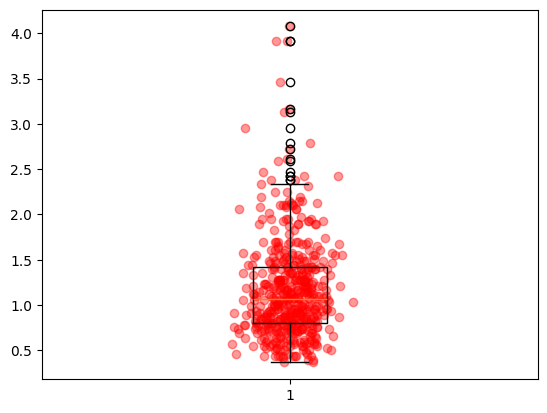

In [269]:
vals, names, xs = [],[],[]
areas_um = areas * (scale[1]*scale[2])
xs.append(np.random.normal(1, 0.04, len(cs_centers_df))) 

plt.boxplot(areas_um);
plt.scatter(xs,areas_um, alpha=0.4, color="red")

We could meaure the area of every spots.

In [270]:
area_to_check = 25
zero_area_centers_df = cs_centers_df[cs_centers_df["area"] == area_to_check]
print(f"Number of spots where we couldn't meaure the area: {len(zero_area_centers_df)}")

Number of spots where we couldn't meaure the area: 7


In [271]:
zero_area_centers_df

,index,Z,Y,X,R,area,diameter,intensitie
219,219,5.0,390.0,670.0,1.982935,25.0,3.672066,78.0
226,226,28.0,63.0,307.0,1.982935,25.0,3.672066,94.0
280,280,46.0,533.0,803.0,1.982935,25.0,3.672066,52.0
339,339,54.0,240.0,499.0,1.982935,25.0,3.672066,73.0
391,391,78.0,673.0,767.0,1.982935,25.0,3.672066,63.0
401,401,36.0,204.0,216.0,1.982935,25.0,3.672066,39.0
424,424,67.0,442.0,778.0,1.982935,25.0,3.672066,43.0


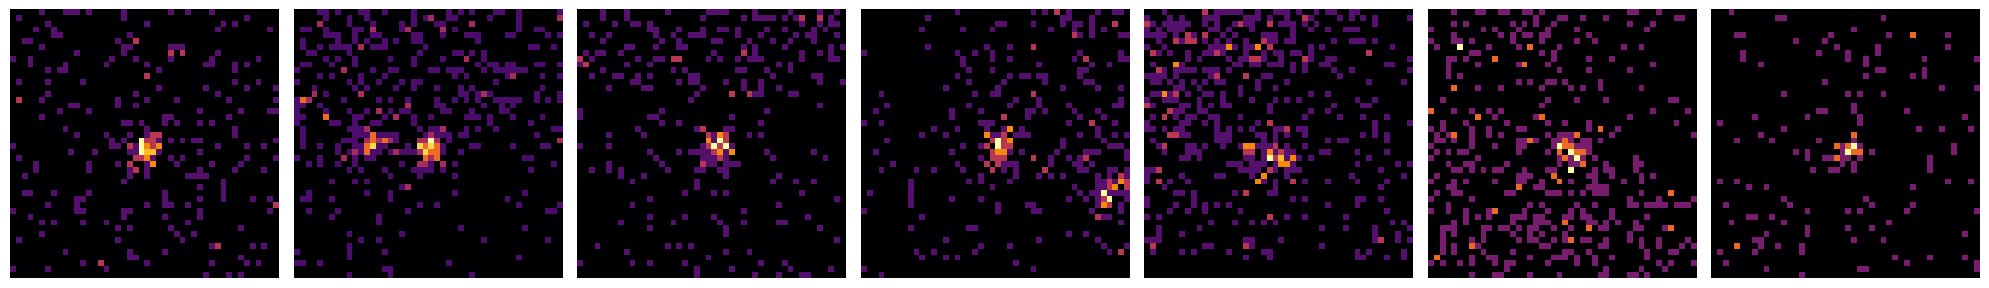

In [272]:
zero_area_centers = zero_area_centers_df[["Z","Y","X"]].values.astype(int)
plots.plot_points_closeup(cs_vol,zero_area_centers,z_margin=1)

Let's check why the area of the first spot can't be computed.

Area: 25
Diameter: 5.641895835477563
Intensity: 78


Text(0.5, 1.0, 'Otsu thresholding')

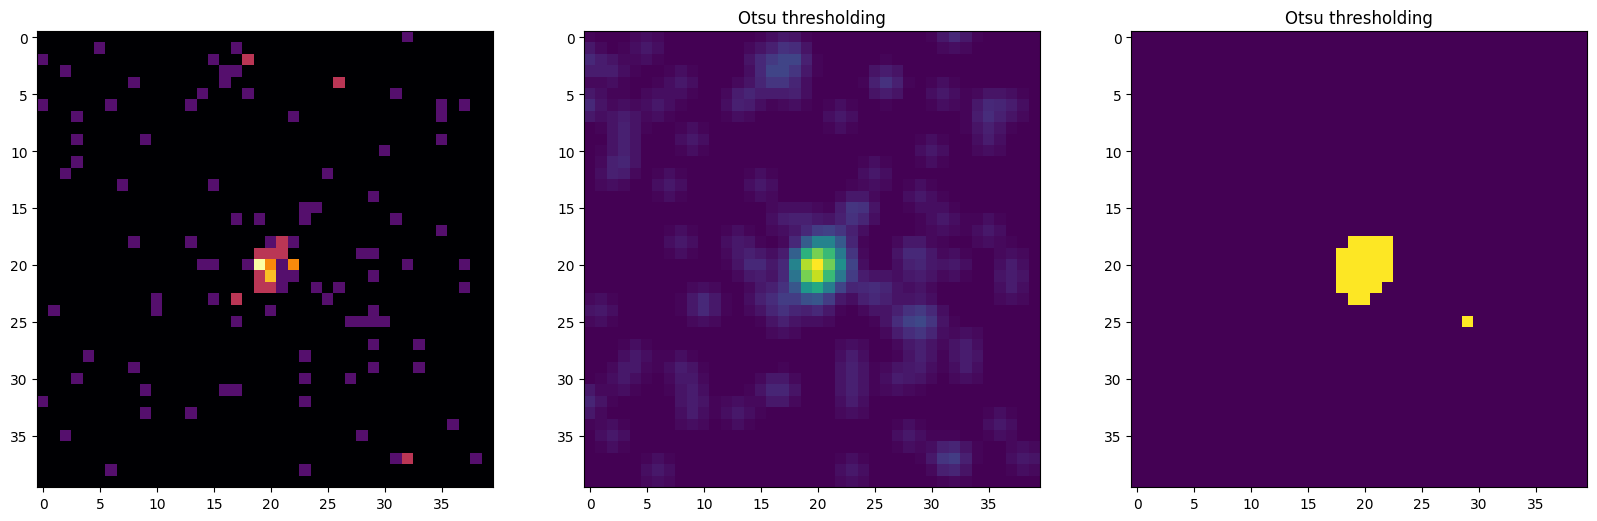

In [273]:
cs_zero_spot = zero_area_centers[0]

z,y,x = cs_zero_spot.astype(int)
window_range = utils.get_window_range(WINDOW_SIZE, cs_zero_spot[1:3], cs_vol.shape[1:3])
wz,wy,wx = utils.get_windowed_coord(WINDOW_SIZE, cs_zero_spot,cs_vol.shape).astype(int)

cs_img = cs_vol[z][window_range]
median_cs_img = ndimage.gaussian_filter(cs_img,sigma=1)
yen_cs_img = median_cs_img > threshold_yen(median_cs_img)

yen_labels, nshapes = label(yen_cs_img, return_num=True)
area = ndimage.sum(yen_cs_img, labels=yen_labels, index=yen_labels[wy,wx])
diameter = np.sqrt(area/np.pi)*2
intensity = median_cs_img[wy,wx]

print(f"Area: {area}")
print(f"Diameter: {diameter}")
print(f"Intensity: {intensity}")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes[0].imshow(cs_img,cmap="inferno")
axes[1].set_title("Original image")
axes[1].imshow(median_cs_img)
axes[1].set_title("Otsu thresholding")
axes[2].set_title("Original image")
axes[2].imshow(yen_cs_img)
axes[2].set_title("Otsu thresholding")

[2.50000000e+001 4.24399158e-314 4.24399158e-314 4.24399158e-314
 4.24399159e-314 4.24399159e-314 4.24399159e-314 4.24399159e-314
 4.24399159e-314 4.24399159e-314 4.24399159e-314 4.24399159e-314
 4.24399159e-314 4.24399159e-314 4.24399160e-314 4.24399160e-314
 4.24399160e-314 4.24399160e-314 4.24399160e-314 4.24399160e-314
 4.24399160e-314 4.24399160e-314 4.24399160e-314 4.24399160e-314
 4.24399161e-314 4.24399161e-314 4.24399161e-314 4.24399161e-314
 4.24399161e-314 4.24399161e-314 4.24399161e-314 4.24399161e-314
 4.24399161e-314 4.24399161e-314 4.24399162e-314 4.24399162e-314
 4.24399162e-314 4.24399162e-314 4.24399162e-314 4.24399162e-314
 4.24399162e-314 4.24399162e-314 4.24399162e-314 4.24399162e-314
 4.24399163e-314 4.24399163e-314 4.24399163e-314 4.24399163e-314
 4.24399163e-314 4.24399163e-314 4.24399163e-314 4.24399163e-314
 4.24399163e-314 4.24399163e-314 4.24399164e-314 4.24399164e-314
 4.24399164e-314 4.24399164e-314 4.24399164e-314 4.24399164e-314
 4.24399164e-314 4.243991

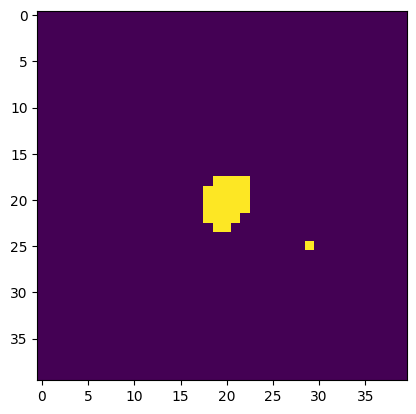

In [274]:
cs_centers = cs_centers_df[["Z","Y","X"]].values

areas = np.empty(len(cs_centers))
diameters = np.empty(len(cs_centers))
intensities = np.empty(len(cs_centers))

cs_center = cs_zero_spot
z,y,x = cs_center.astype(int)
window_range = utils.get_window_range(WINDOW_SIZE, cs_center[1:3], cs_vol.shape[1:3])
wz,wy,wx = utils.get_windowed_coord(WINDOW_SIZE, cs_center,cs_vol.shape).astype(int)

cs_img = cs_vol[z][window_range]
#median_cs_img = ndimage.median_filter(cs_img,size=3)
gaussian_cs_img = ndimage.gaussian_filter(cs_img,sigma=1)
yen_cs_img = gaussian_cs_img > threshold_yen(gaussian_cs_img)

plt.imshow(yen_cs_img)

yen_labels, nshapes = label(yen_cs_img, return_num=True)
areas[0] = ndimage.sum(yen_cs_img, labels=yen_labels, index=yen_labels[wy,wx])
diameters[0] = np.sqrt(area/np.pi)*2
intensities[0] = gaussian_cs_img[wy,wx]

print(areas)